# Dissertation figures — Synthetic Pelvic MRI Augmentation

Publication-quality figures generated **from the project's own result files**
(`metrics/master_metrics.csv`, `metrics/variance_study_summary.json`,
`*_dsc_summary.json`). Run the notebook top-to-bottom: every figure renders
inline, and the **final cell saves them all to `figures/` at 300 dpi**.

Because the charts read the result files live, re-running after a pending
experiment finishes will update the affected figures automatically.

> **Setup:** open Jupyter from the repository root so the relative paths
> resolve. If you run from elsewhere, edit `ROOT` in the first code cell.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- where things live (edit ROOT if you run from elsewhere) ----
ROOT = Path.cwd()
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

# ---- house style: clean, consistent, print-ready ----
plt.rcParams.update({
    "figure.dpi": 120,          # crisp inline preview
    "savefig.dpi": 300,         # print quality on save
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
    "legend.frameon": False,
})

# consistent palette across every figure
C = {
    "baseline": "#404040",   # real-only reference line
    "concat":   "#C44E52",   # concat conditioning (the failure mode)
    "concat_l": "#E39399",   # lighter concat
    "spade":    "#4C72B0",   # SPADE conditioning
    "spade_l":  "#9BB4D6",   # lighter SPADE
    "phase2":   "#8172B3",   # cross-domain Phase 2
    "accent":   "#DD8452",   # highlight (e.g. n=3 reading)
}

BASELINE = 0.290   # RAovSeg real-only ovary DSC (Liang et al., 2025) — verified reproduction

FIGS = {}          # every figure is collected here for the save-all cell
print("ROOT      :", ROOT)
print("FIG_DIR   :", FIG_DIR)

ROOT      : /sessions/gracious-determined-maxwell/mnt/EndometriosisDataset
FIG_DIR   : /sessions/gracious-determined-maxwell/mnt/EndometriosisDataset/figures


## 1. Load the result files

All downstream DSC numbers come from the per-seed summary JSONs; all generator
quality metrics come from `master_metrics.csv`. Nothing here is hand-typed.

In [2]:
def load_json(name):
    p = ROOT / name
    if not p.exists():
        p = ROOT / "metrics" / Path(name).name
    return json.loads(p.read_text())

def seed_means(summary):
    "Mean DSC per completed seed; ignores not_started / failed seeds."
    return np.array([s["dsc_mean"] for s in summary["seeds"] if s.get("status") == "ok"])

variance   = load_json("metrics/variance_study_summary.json")
spade_seeds = seed_means(variance)                       # SPADE v3, n=8 seeds
exp2   = seed_means(load_json("exp2_dsc_summary.json"))       # Phase 2, lambda=0.01
exp2C  = seed_means(load_json("exp2_pathC_dsc_summary.json")) # Phase 2, Path C
lam05  = seed_means(load_json("lam05_dsc_summary.json"))      # Phase 2, lambda=0.05

quality = pd.read_csv(ROOT / "metrics" / "master_metrics.csv")

print(f"SPADE v3 seeds (n={spade_seeds.size}): "
      f"mean={spade_seeds.mean():.3f}  sd={spade_seeds.std():.3f}")
print(f"Phase 2 exp2   (n={exp2.size}):  mean={exp2.mean():.3f}")
print(f"Phase 2 pathC  (n={exp2C.size}): mean={exp2C.mean():.3f}")
print(f"Phase 2 lam05  (n={lam05.size}): mean={lam05.mean():.3f}")
quality[["variant","fid","hist_kl","lpips_nn_mean",
         "CLR_uterus","CLR_ov_L","CLR_em"]].round(3)

SPADE v3 seeds (n=8): mean=0.178  sd=0.050
Phase 2 exp2   (n=3):  mean=0.020
Phase 2 pathC  (n=3): mean=0.152
Phase 2 lam05  (n=3): mean=0.117


,variant,fid,hist_kl,lpips_nn_mean,CLR_uterus,CLR_ov_L,CLR_em
0,exp1a_ddpm_concat,188.217,8.153,0.824,0.013,0.043,0.028
1,exp1b_ddpm_spade,200.054,6.894,0.745,0.407,0.495,0.532
2,exp1c_concat,166.479,5.793,0.773,0.069,0.080,0.063
3,exp1c_spade,188.136,7.205,0.699,0.405,0.297,0.420


## 2. Downstream augmentation trajectory (v1 → v2 → v3)

The headline result: across every preprocessing-fix level, neither conditioning
scheme reaches the real-only baseline. SPADE climbs but plateaus; concat collapses.

*v1/v2 values are the canonical figures from the dissertation drafts; the v3
SPADE point is computed live from `variance_study_summary.json`.*

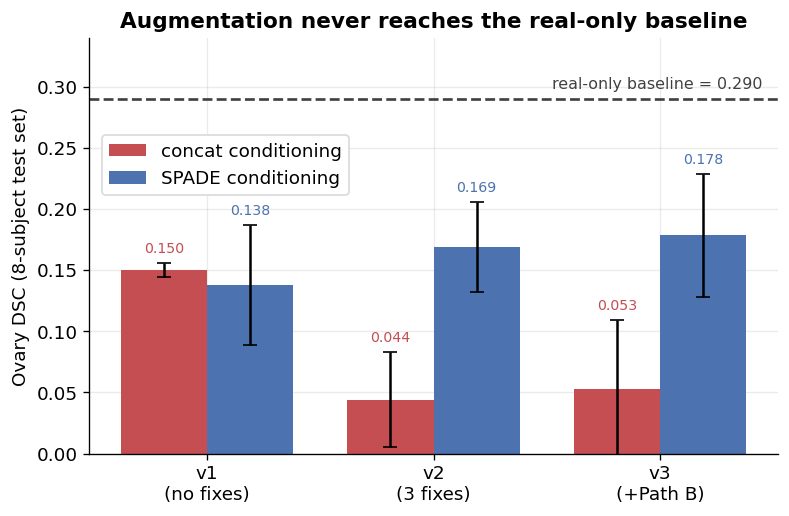

In [3]:
levels     = ["v1\n(no fixes)", "v2\n(3 fixes)", "v3\n(+Path B)"]
concat_dsc = [0.150, 0.044, 0.053];  concat_err = [0.006, 0.039, 0.056]
spade_dsc  = [0.138, 0.169, float(spade_seeds.mean())]
spade_err  = [0.049, 0.037, float(spade_seeds.std())]

x = np.arange(len(levels)); w = 0.38
fig, ax = plt.subplots(figsize=(7.4, 4.5))
b1 = ax.bar(x - w/2, concat_dsc, w, yerr=concat_err, capsize=4,
            color=C["concat"], label="concat conditioning")
b2 = ax.bar(x + w/2, spade_dsc,  w, yerr=spade_err,  capsize=4,
            color=C["spade"],  label="SPADE conditioning")
ax.axhline(BASELINE, ls="--", lw=1.6, color=C["baseline"])
ax.text(len(levels) - 0.55, BASELINE + 0.006,
        f"real-only baseline = {BASELINE:.3f}", ha="right", va="bottom",
        color=C["baseline"], fontsize=9.5)
for xi, v, e in zip(x - w/2, concat_dsc, concat_err):
    ax.text(xi, v + e + 0.006, f"{v:.3f}", ha="center", va="bottom", fontsize=8.5, color=C["concat"])
for xi, v, e in zip(x + w/2, spade_dsc, spade_err):
    ax.text(xi, v + e + 0.006, f"{v:.3f}", ha="center", va="bottom", fontsize=8.5, color=C["spade"])
ax.set_xticks(x); ax.set_xticklabels(levels)
ax.set_ylabel("Ovary DSC (8-subject test set)")
ax.set_title("Augmentation never reaches the real-only baseline")
ax.set_ylim(0, 0.34)
ax.legend(loc="lower left", bbox_to_anchor=(0.005, 0.60),
          frameon=True, facecolor="white", framealpha=1.0, edgecolor="0.85")
FIGS["downstream_trajectory"] = fig
plt.show()

## 3. Phase 2 cross-domain collapse

Moving the generator cross-domain (D1 T2 -> D2 T2FS) does not recover the gap —
it makes things dramatically worse. `exp2` (lambda=0.01) collapses to near-zero.

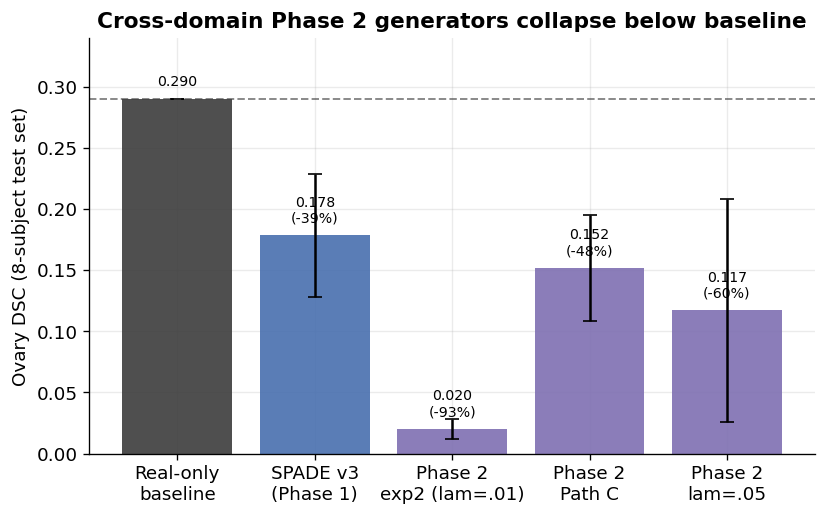

In [4]:
labels = ["Real-only\nbaseline", "SPADE v3\n(Phase 1)",
          "Phase 2\nexp2 (lam=.01)", "Phase 2\nPath C", "Phase 2\nlam=.05"]
vals   = [BASELINE, spade_seeds.mean(), exp2.mean(), exp2C.mean(), lam05.mean()]
errs   = [0, spade_seeds.std(), exp2.std(), exp2C.std(), lam05.std()]
colors = [C["baseline"], C["spade"], C["phase2"], C["phase2"], C["phase2"]]

fig, ax = plt.subplots(figsize=(7.8, 4.5))
bars = ax.bar(labels, vals, yerr=errs, capsize=4, color=colors, alpha=0.92)
ax.axhline(BASELINE, ls="--", lw=1.2, color=C["baseline"], alpha=0.6)
for b, v in zip(bars, vals):
    txt = f"{v:.3f}" if abs(v - BASELINE) < 1e-9 else f"{v:.3f}\n({(v-BASELINE)/BASELINE*100:+.0f}%)"
    ax.text(b.get_x() + b.get_width()/2, v + 0.008, txt, ha="center", va="bottom", fontsize=8.5)
ax.set_ylabel("Ovary DSC (8-subject test set)")
ax.set_title("Cross-domain Phase 2 generators collapse below baseline")
ax.set_ylim(0, 0.34)
FIGS["phase2_collapse"] = fig
plt.show()

## 4. Seed variance study (n = 8)

A methodological point: the optimistic reading came from only the first 3 seeds
(mean 0.218). Five more seeds drag the mean down to 0.178, well below baseline —
so small seed counts overstate augmentation benefit. Fully data-driven from
`variance_study_summary.json`.

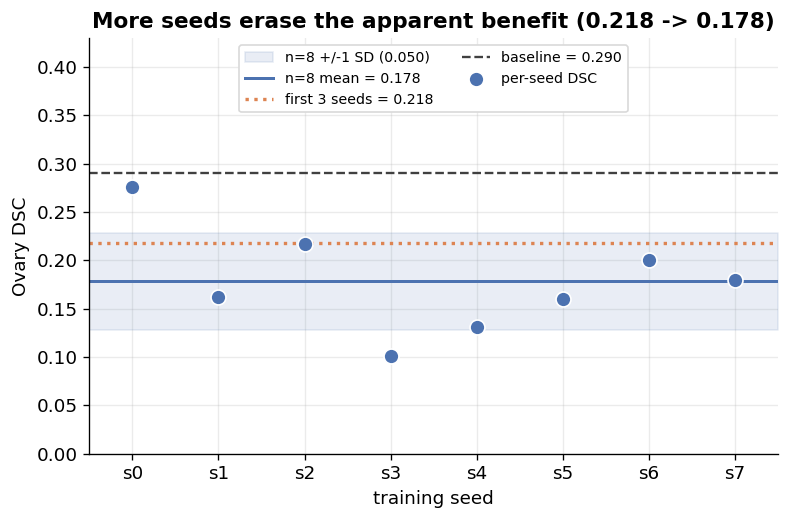

In [5]:
n8_mean, n8_std = spade_seeds.mean(), spade_seeds.std()
n3_mean = spade_seeds[:3].mean()   # original optimistic n=3 reading
xs = np.arange(len(spade_seeds))

fig, ax = plt.subplots(figsize=(7.4, 4.5))
ax.fill_between([-0.5, len(spade_seeds) - 0.5], n8_mean - n8_std, n8_mean + n8_std,
                color=C["spade"], alpha=0.12, label=f"n=8 +/-1 SD ({n8_std:.3f})")
ax.axhline(n8_mean, color=C["spade"], lw=1.8, label=f"n=8 mean = {n8_mean:.3f}")
ax.axhline(n3_mean, color=C["accent"], ls=":", lw=2.0, label=f"first 3 seeds = {n3_mean:.3f}")
ax.axhline(BASELINE, ls="--", lw=1.4, color=C["baseline"], label=f"baseline = {BASELINE:.3f}")
ax.scatter(xs, spade_seeds, s=80, color=C["spade"], edgecolor="white", zorder=5, label="per-seed DSC")
ax.set_xticks(xs); ax.set_xticklabels([f"s{i}" for i in xs])
ax.set_xlim(-0.5, len(spade_seeds) - 0.5); ax.set_ylim(0, 0.43)
ax.set_xlabel("training seed"); ax.set_ylabel("Ovary DSC")
ax.set_title("More seeds erase the apparent benefit (0.218 -> 0.178)")
ax.legend(fontsize=8.5, ncol=2, loc="upper center",
          frameon=True, facecolor="white", framealpha=1.0, edgecolor="0.85")
FIGS["variance_study"] = fig
plt.show()

## 5. Generator quality metrics across the 2x2

No single variant wins on distributional quality: concat variants win FID and
hist_KL, a SPADE variant wins LPIPS. These standard metrics therefore fail to
predict downstream utility — motivating the task-relevant CLR metric (next).
Read live from `master_metrics.csv` (concat = red, SPADE = blue).

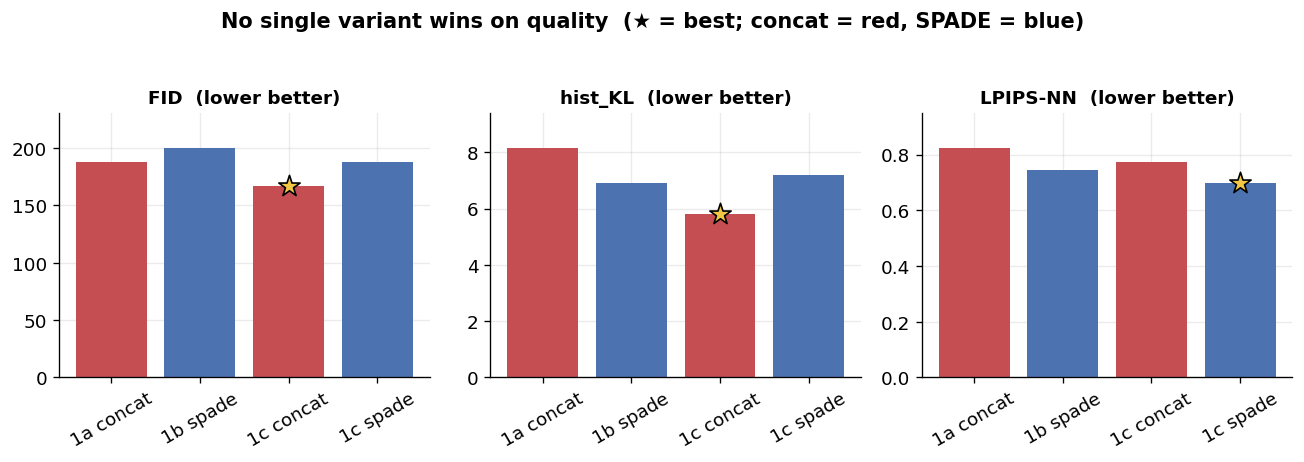

In [6]:
qm = quality.copy()
qm["short"] = ["1a concat", "1b spade", "1c concat", "1c spade"]
bar_colors = [C["concat"], C["spade"], C["concat"], C["spade"]]

cols = [("fid", "FID  (lower better)"),
        ("hist_kl", "hist_KL  (lower better)"),
        ("lpips_nn_mean", "LPIPS-NN  (lower better)")]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.9))
for ax, (col, title) in zip(axes, cols):
    ax.bar(qm["short"], qm[col], color=bar_colors)
    best = qm[col].idxmin()
    ax.scatter(best, qm[col].iloc[best], marker="*", s=180,
               color="#F2C744", edgecolor="black", zorder=5, clip_on=False)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    ax.margins(y=0.15)
fig.suptitle("No single variant wins on quality  (★ = best; concat = red, SPADE = blue)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
FIGS["quality_metrics"] = fig
plt.show()

## 6. Per-organ localisation (CLR)

The task-relevant metric. Counterfactual Localisation Ratio measures whether
removing an organ's label channel changes the image *locally* at that organ.
SPADE variants localise (CLR ~0.3-0.5); concat variants do not (CLR ~0.03-0.08) —
the mechanism behind "concat is architecturally locked out".

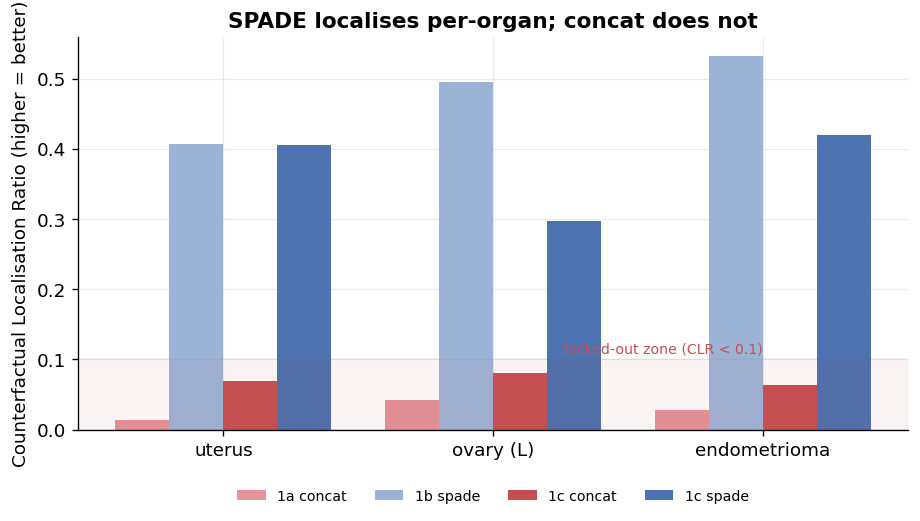

In [7]:
chans = {"uterus": "CLR_uterus", "ovary (L)": "CLR_ov_L", "endometrioma": "CLR_em"}
cx = np.arange(len(chans)); w = 0.2
var_colors = [C["concat_l"], C["spade_l"], C["concat"], C["spade"]]

fig, ax = plt.subplots(figsize=(7.8, 4.5))
for i, (_, row) in enumerate(qm.iterrows()):
    vals = [row[c] for c in chans.values()]
    ax.bar(cx + (i - 1.5) * w, vals, w, label=row["short"], color=var_colors[i])
ax.axhspan(0, 0.1, color="#C44E52", alpha=0.06)
ax.text(len(chans) - 1, 0.105, "locked-out zone (CLR < 0.1)", ha="right",
        va="bottom", fontsize=8.5, color=C["concat"])
ax.set_xticks(cx); ax.set_xticklabels(list(chans.keys()))
ax.set_ylabel("Counterfactual Localisation Ratio (higher = better)")
ax.set_title("SPADE localises per-organ; concat does not")
ax.legend(ncol=4, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
FIGS["clr_localisation"] = fig
plt.show()

## Save every figure to `figures/`

The line you asked for: writes all figures above to the project's `figures/`
folder at 300 dpi. Re-run any time after regenerating a chart.

In [8]:
saved = []
for name, fig in FIGS.items():
    out = FIG_DIR / f"fig_{name}.png"
    fig.savefig(out)
    saved.append(out.name)

print(f"Saved {len(saved)} figures to {FIG_DIR}")
for s in saved:
    print("  -", s)

Saved 5 figures to /sessions/gracious-determined-maxwell/mnt/EndometriosisDataset/figures
  - fig_downstream_trajectory.png
  - fig_phase2_collapse.png
  - fig_variance_study.png
  - fig_quality_metrics.png
  - fig_clr_localisation.png
